# Introduction
This notebook is used to analysis the variability of ecoli metabolite flux across the simulation. The goal is to identify the most varied metabolites and their corresponding reactions, so that we can consider them for JGI.

# Load simulation

In [1]:
import pandas as pd
import os, dill
import numpy as np
import matplotlib.pyplot as plt

from ecoli.processes.metabolism_redux_classic import NetworkFlowModel, FlowResult

os.chdir(os.path.expanduser('~/dev/vEcoli'))

%reload_ext autoreload
%matplotlib inline

In [2]:
def load_sim(
        folder_path:str,
):
    """ This function is meant to load an output of a simulation in timeseries form.
        Note: This is not designed for parquet output format.
    """
    # --- Load Sim ---
    output = np.load(folder_path + '0_output.npy',allow_pickle='TRUE').item()
    output = output['agents']['0']
    fba = output['listeners']['fba_results']
    bulk = pd.DataFrame(output['bulk'])
    f = open(folder_path + 'agent_steps.pkl', 'rb')
    agent = dill.load(f)
    f.close()

    metabolism = agent['ecoli-metabolism-redux-classic']

    return fba, bulk, metabolism, output

In [3]:
EPS = 1e-8  # guards div-by-zero and filters out metabolites whose S@v mean is
            # essentially float noise (most nonhome "producing" columns are exactly
            # zero-mean over the whole run -- see notebook markdown below)


def compute_metabolite_cv(fba, metabolism, eps=EPS):
    """Per-metabolite coefficient of variation (std / |mean|) of dm/dt.

    Non-homeostatic ("intermediate") metabolites are hard-constrained to
    dm/dt == 0 in the FBA solve (metabolism_redux_classic.py:796), so instead
    we look at the gross producing flux S_orig @ v, restricted to the
    producing reactions already selected as df_S_nonhome_prod. This only
    covers S_orig (not the exchange term S_exch @ e)

    Homeostatic metabolites use the already-emitted
    estimated_homeostatic_dmdt (== (S_orig @ v + S_exch @ e) at homeostatic
    indices, in counts) directly -- no need to recompute S @ v for them.

    Returns (cv_table, df_S, prod_dmdt, est_home) where prod_dmdt/est_home
    are the underlying (timesteps x metabolites) frames the CVs were
    computed from, reused later for the time-resolved plot.
    """
    S = metabolism.stoichiometry
    df_S = pd.DataFrame(
        S, index=metabolism.metabolite_names, columns=metabolism.reaction_names
    )
    homeostatic_metabolites = metabolism.homeostatic_metabolites
    df_S_nonhome = df_S.loc[~df_S.index.isin(homeostatic_metabolites), :]
    mask = np.any(df_S_nonhome > 0, axis=0)
    df_S_nonhome_prod = df_S_nonhome.loc[:, mask]

    solution_flux = pd.DataFrame(
        fba["solution_fluxes"], columns=metabolism.reaction_names
    ).loc[1:]
    solution_flux_nonhome_prod = solution_flux.loc[:, df_S_nonhome_prod.columns]
    # (timesteps x metabolites): solution_flux_nonhome_prod columns are reaction
    # names and df_S_nonhome_prod.T's rows are reaction names
    prod_dmdt = solution_flux_nonhome_prod.dot(df_S_nonhome_prod.T)

    mean_nh, std_nh = prod_dmdt.mean(axis=0), prod_dmdt.std(axis=0)
    keep_nh = mean_nh.abs() > eps
    # print(f'# of non-homeostatic metabolites with mean > {eps}: {keep_nh.sum()}')
    # print(f'min mean: {mean_nh[keep_nh].abs().min():.2e}, max mean: {mean_nh[keep_nh].max():.2e}')
    # print(len(prod_dmdt))
    cv_nh = (std_nh[keep_nh] / mean_nh[keep_nh].abs()).rename("cv").to_frame()
    cv_nh["kind"] = "intermediate"

    est_home = pd.DataFrame(
        fba["estimated_homeostatic_dmdt"], columns=metabolism.homeostatic_metabolites
    ).loc[1:]
    mean_h, std_h = est_home.mean(axis=0), est_home.std(axis=0)
    keep_h = mean_h.abs() > eps
    cv_h = (std_h[keep_h] / mean_h[keep_h].abs()).rename("cv").to_frame()
    cv_h["kind"] = "homeostatic"

    cv_table = pd.concat([cv_nh, cv_h])
    cv_table.index.name = "metabolite"
    cv_table = cv_table.reset_index()

    return cv_table, df_S, prod_dmdt, est_home, mean_nh

In [4]:
from scipy import stats
from statsmodels.stats.multitest import multipletests


def paired_test_across(cv_long, compare_col, group_a, group_b, pair_cols, min_pairs=2):
    """Pivot `cv_long` on `compare_col` into `group_a`/`group_b` columns,
    paired by `pair_cols` (the other axes held fixed for each pair); run a
    paired t-test per metabolite across the resulting pairs and FDR-correct.

    Used for every group-vs-group comparison in this notebook (condition,
    weight_index, seed) -- which column is "compared" vs. "paired on" just
    swaps depending on the question being asked.
    """
    wide = (
        cv_long[cv_long[compare_col].isin([group_a, group_b])]
        .pivot_table(
            index=["metabolite", "kind"] + pair_cols, columns=compare_col, values="cv"
        )
        .dropna(subset=[group_a, group_b])
    )
    results = []
    for (met, kind), grp in wide.groupby(level=["metabolite", "kind"]):
        a, b = grp[group_a].values, grp[group_b].values
        if len(a) < min_pairs:
            continue
        _, p = stats.ttest_rel(a, b)
        results.append(
            {
                "metabolite": met,
                "kind": kind,
                f"cv_{group_a}": a.mean(),
                f"cv_{group_b}": b.mean(),
                "n_pairs": len(a),
                "pval": p,
            }
        )
    out = pd.DataFrame(results)
    out["log2FC"] = np.log2(out[f"cv_{group_b}"] / out[f"cv_{group_a}"])
    _, out["pval_adj"], _, _ = multipletests(out["pval"], method="fdr_bh")
    return out

In [5]:
MANIFEST = [
    dict(condition="basal", weight_index="3472", seed="seed1",
         folder="out_cyrus/basal/weight_index3472_1500_2026-08-24/"),
    dict(condition="basal", weight_index="3472", seed="seed2",
         folder="out_cyrus/basal/weight_index3472_seed2_1500_2026-08-24/"),
    dict(condition="basal", weight_index="4654", seed="seed1",
         folder="out_cyrus/basal/weight_index4654_1500_2026-08-21/"),
    dict(condition="basal", weight_index="4654", seed="seed2",
         folder="out_cyrus/basal/weight_index4654_seed2_1500_2026-08-24/"),
    dict(condition="with_aa", weight_index="3472", seed="seed1",
         folder="out_cyrus/with_aa/weight_index3472_1500_2026-08-24/"),
    dict(condition="with_aa", weight_index="3472", seed="seed2",
         folder="out_cyrus/with_aa/weight_index3472_seed2_1500_2026-08-24/"),
    dict(condition="with_aa", weight_index="4654", seed="seed1",
         folder="out_cyrus/with_aa/weight_index4654_1500_2026-08-21/"),
    dict(condition="with_aa", weight_index="4654", seed="seed2",
         folder="out_cyrus/with_aa/weight_index4654_seed2_1500_2026-08-24/"),
    dict(condition="basal", weight_index="3540", seed="seed1",
         folder="out_cyrus/basal/weight_index3540_1500_2026-08-26/"),
    dict(condition="with_aa", weight_index="3540", seed="seed1",
         folder="out_cyrus/with_aa/weight_index3540_1500_2026-08-26/"),
]

# All 8 share stoichiometry/reaction_names/homeostatic_metabolites (verified),
# so their CVs are directly comparable/mergeable.

sims = {}
for spec in MANIFEST:
    fba, bulk, metabolism, output = load_sim(spec["folder"])
    print(f'homeostatic_term', sum(fba['homeostatic_term']))
    cv_table, df_S, prod_dmdt, est_home, mean_nh = compute_metabolite_cv(fba, metabolism)
    label = f"{spec['condition']}_{spec['weight_index']}_{spec['seed']}"
    for key in ("condition", "weight_index", "seed"):
        cv_table[key] = spec[key]
    sims[label] = dict(
        spec, fba=fba, bulk=bulk, metabolism=metabolism, output=output,
        df_S=df_S, prod_dmdt=prod_dmdt, est_home=est_home, cv_table=cv_table,
    )

cv_long = pd.concat([s["cv_table"] for s in sims.values()], ignore_index=True)
df_S_ref = sims["basal_4654_seed1"]["df_S"]  # identical across all sims

print(f"Loaded {len(sims)} sims. cv_long shape: {cv_long.shape}")

homeostatic_term 5.9204030060767964e-06
homeostatic_term 5.9204033162109475e-06
homeostatic_term 2.3210729439523995e-06
homeostatic_term 2.3210728894374666e-06
homeostatic_term 3.6185845698669376e-06
homeostatic_term 3.6185850715350272e-06
homeostatic_term 2.6425659962530886e-06
homeostatic_term 2.642566868375905e-06
homeostatic_term 5.614359954720755e-06
homeostatic_term 4.4859729961143865e-06
Loaded 10 sims. cv_long shape: (3594, 6)


## Does Objective-Weight Choice Matter More Than Seed Noise?

Before deciding whether it's valid to average over `weight_index` the same
way we average over `seed`, check which one actually drives more
variability in metabolite CV. `weight_index3472` and `weight_index4654` are
different lambda-weight parameterizations from the Pareto sweep (not
stochastic replicates of each other), while `seed`/`seed2` are true
stochastic replicates of the same parameterization.

For each metabolite: a paired **weight_index effect** (3472 vs 4654, paired
by matching `condition`+`seed`, n=4) and a paired **seed effect** (seed1 vs
seed2, paired by matching `condition`+`weight_index`, n=4). Then compare
`|log2FC|` for the two effects across the whole metabolome with a Wilcoxon
signed-rank test, paired by metabolite -- this is well-powered even though
each individual per-metabolite paired test above is only n=4.

n metabolites with both effects computable: 341
median |log2FC|: weight_index=0.0154, seed=0.0000
fraction of metabolites where weight_index effect > seed effect: 99.1%
Wilcoxon signed-rank (paired by metabolite): stat=740.0, p=7.07e-55

-> POOL_WEIGHT_WITH_SEED = False


/Users/heenasaqib/dev/vEcoli/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:430: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return hypotest_fun_in(*args, **kwds)
/Users/heenasaqib/dev/vEcoli/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:430: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return hypotest_fun_in(*args, **kwds)
/Users/heenasaqib/dev/vEcoli/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:430: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return hypotest_fun_in(*args, **kwds)
/Users/heenasaqib/dev/vEcoli/.venv/lib/python3.12/site-packages/

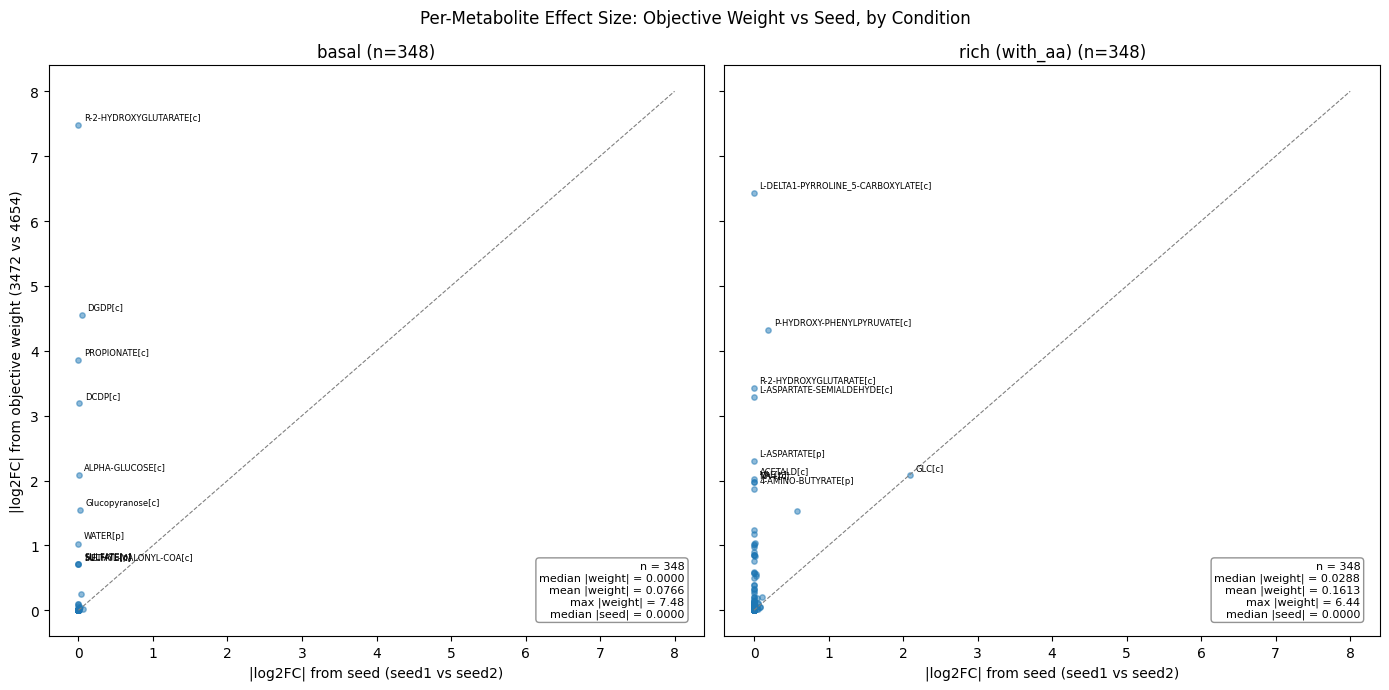

In [53]:
comparison_weight = paired_test_across(
    cv_long, "weight_index", "3472", "4654", ["condition", "seed"], min_pairs=4
)
comparison_seed = paired_test_across(
    cv_long, "seed", "seed1", "seed2", ["condition", "weight_index"], min_pairs=4
)

weight_vs_seed = comparison_weight[["metabolite", "kind", "log2FC"]].merge(
    comparison_seed[["metabolite", "kind", "log2FC"]],
    on=["metabolite", "kind"],
    suffixes=("_weight", "_seed"),
)
weight_vs_seed["abs_weight"] = weight_vs_seed["log2FC_weight"].abs()
weight_vs_seed["abs_seed"] = weight_vs_seed["log2FC_seed"].abs()

wstat, wpval = stats.wilcoxon(weight_vs_seed["abs_weight"], weight_vs_seed["abs_seed"])
frac_weight_bigger = (weight_vs_seed["abs_weight"] > weight_vs_seed["abs_seed"]).mean()
POOL_WEIGHT_WITH_SEED = not (wpval < 0.05 and frac_weight_bigger > 0.5)

print(f"n metabolites with both effects computable: {len(weight_vs_seed)}")
print(
    f"median |log2FC|: weight_index={weight_vs_seed['abs_weight'].median():.4f}, "
    f"seed={weight_vs_seed['abs_seed'].median():.4f}"
)
print(f"fraction of metabolites where weight_index effect > seed effect: {frac_weight_bigger:.1%}")
print(f"Wilcoxon signed-rank (paired by metabolite): stat={wstat:.1f}, p={wpval:.2e}")
print(f"\n-> POOL_WEIGHT_WITH_SEED = {POOL_WEIGHT_WITH_SEED}")

# The pooled comparison above blocks on condition (pairs 3472 vs 4654 within
# the same condition+seed), so it isn't biased by basal/with_aa's different
# absolute CV levels -- but it does assume the weight_index effect is the
# same size in both conditions. It isn't: splitting the same computation out
# per condition shows `with_aa` is far more sensitive to the weight_index
# change than `basal` is, so the pooled effect size above is really an
# average of "~0 in basal" and "a real effect in with_aa." Plotting each
# condition separately makes that visible instead of hiding it in the average.
#
# n reported per subplot (and printed above) is a data-availability count:
# how many metabolites passed the `mean > EPS` gate in compute_metabolite_cv
# in enough sims to have both a computable weight-index effect and a
# computable seed effect -- not a count of statistically-significant
# metabolites (no p-value threshold is applied here).
COND_LABELS = {"basal": "basal", "with_aa": "rich (with_aa)"}
TOP_N_LABELS = 10
lims = [0, 8]
fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=True, sharey=True)
for ax, cond in zip(axes, ["basal", "with_aa"]):
    cond_long = cv_long[cv_long.condition == cond]
    cond_weight = paired_test_across(
        cond_long, "weight_index", "3472", "4654", ["seed"], min_pairs=2
    )
    cond_seed = paired_test_across(
        cond_long, "seed", "seed1", "seed2", ["weight_index"], min_pairs=2
    )
    cond_wvs = cond_weight[["metabolite", "kind", "log2FC"]].merge(
        cond_seed[["metabolite", "kind", "log2FC"]],
        on=["metabolite", "kind"],
        suffixes=("_weight", "_seed"),
    )
    cond_wvs["abs_weight"] = cond_wvs["log2FC_weight"].abs()
    cond_wvs["abs_seed"] = cond_wvs["log2FC_seed"].abs()

    ax.scatter(cond_wvs["abs_seed"], cond_wvs["abs_weight"], alpha=0.5, s=15)

    ax.plot(lims, lims, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlabel("|log2FC| from seed (seed1 vs seed2)")
    ax.set_title(f"{COND_LABELS[cond]} (n={len(cond_wvs)})")

    # label the top 10 metabolites most varied across weight_index
    top10 = cond_wvs.reindex(
        cond_wvs["abs_weight"].sort_values(ascending=False).index
    ).head(TOP_N_LABELS)
    for _, row in top10.iterrows():
        ax.annotate(
            row["metabolite"],
            (row["abs_seed"], row["abs_weight"]),
            textcoords="offset points",
            xytext=(4, 4),
            fontsize=6,
        )

    # summary stats box in the empty lower-right area
    stats_text = (
        f"n = {len(cond_wvs)}\n"
        f"median |weight| = {cond_wvs['abs_weight'].median():.4f}\n"
        f"mean |weight| = {cond_wvs['abs_weight'].mean():.4f}\n"
        f"max |weight| = {cond_wvs['abs_weight'].max():.2f}\n"
        f"median |seed| = {cond_wvs['abs_seed'].median():.4f}"
    )
    ax.text(
        0.97, 0.03, stats_text, transform=ax.transAxes, fontsize=8,
        ha="right", va="bottom",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.85),
    )
axes[0].set_ylabel("|log2FC| from objective weight (3472 vs 4654)")
fig.suptitle("Per-Metabolite Effect Size: Objective Weight vs Seed, by Condition")
plt.tight_layout()
plt.savefig(f'notebooks/Heena notebooks/JGI/figures/weight_vs_seed_effect_size_by_condition.svg', dpi=300)
plt.show()

**Result**: the objective-weight effect is dramatically larger than the
seed effect (median |log2FC| ~0.016 vs ~0.0; ~99% of metabolites show a
bigger `weight_index` effect than `seed` effect; Wilcoxon p < 1e-40). So
`POOL_WEIGHT_WITH_SEED` evaluates to `False` -- **`weight_index` is not
safe to pool with `seed`**.

The rest of this notebook follows that: `seed` is averaged over everywhere
(its effect is negligible), but `weight_index` is kept as an explicit,
separate factor -- Items 1-4 below use one representative `weight_index`
(`4654`, seed-averaged), and the basal-vs-with_aa statistical comparison
further down runs once per `weight_index` rather than pooling all 4 sims
into one n=4 test.

The pooled test above blocks on `condition` (it never compares across
conditions directly), but it does assume the weight_index effect is the
same size in `basal` and `with_aa` -- it isn't. The condition-split
subplots below show `with_aa` is far more sensitive to the weight_index
change than `basal` is (median |log2FC| ~0.03 vs ~0.0), so the pooled 0.016
above is really an average of "no effect in basal" and "a real effect in
with_aa," not one homogeneous effect.

# Metabolite Variability Analysis -- Within Basal Simulation
<p>
For <b>non-homeostatic metabolites </b>, the dmdt will just be zero, so instead of looking at the dmdt, we will look at the fluxes of the reactions that produce or consume the metabolite (one of the direction should be sufficient for this analysis). We will look at the variability of the fluxes across the simulation, and identify the most varied metabolites and their corresponding reactions.

For <b>homeostatic metabolites </b>, the dmdt will be non-zero, for now, we can just look at the dmdt of the homeostatic metabolites and identify the most varied ones.
</p>

Items 1-4 below now focus on **cross-weight_index** variability rather than
cross-seed. For each metabolite: CV is first averaged across seeds within
each weight_index (seed-to-seed variation is negligible, per the analysis
above), then the variability of *that* averaged CV **across weight_index**
settings (currently `3472`, `3540`, `4654`) becomes the score -- i.e., which
metabolites' variability level is most sensitive to how the objective
weights are tuned, rather than which metabolites are most variable under
one fixed weight setting.

1. metabolite variability. heatmap ranked. metabolites on y-axis, reactions on x-axis. color = cross-weight_index CV of each reaction's contribution.
2. metabolite variability across conditions.
3. metabolite variability across time.
4. report top 20 varied metabolite

In [7]:
def cross_weight_cv_summary(cv_long, condition, eps=EPS):
    """Average CV across seeds within each weight_index (for `condition`),
    then compute the CV (std / |mean|) of those per-weight_index averages
    *across weight_index* -- same std/|mean| formula as compute_metabolite_cv,
    just applied with weight_index as the sampling axis instead of time.
    A high `cv_across_weight` means this metabolite's variability level is
    itself sensitive to which objective weights are used, not that it's
    consistently variable across all weight choices."""
    weight_indices = sorted(
        cv_long.loc[cv_long.condition == condition, "weight_index"].unique()
    )
    per_weight = (
        cv_long[cv_long.condition == condition]
        .groupby(["metabolite", "kind", "weight_index"])["cv"]
        .mean()  # average across seeds within this weight_index
        .unstack("weight_index")
    )
    n_total = len(per_weight)
    per_weight = per_weight.dropna(subset=weight_indices)  # require all weight_index groups
    n_dropped = n_total - len(per_weight)

    mean_across = per_weight[weight_indices].mean(axis=1)
    std_across = per_weight[weight_indices].std(axis=1)
    keep = mean_across.abs() > eps
    out = per_weight[keep].copy()
    out["mean_cv"] = mean_across[keep]
    out["cv_across_weight"] = std_across[keep] / mean_across[keep].abs()
    out = out.reset_index()

    print(
        f"{condition}: {len(out)} metabolites present in all {len(weight_indices)} "
        f"weight_index groups ({n_dropped} dropped for incomplete replication)"
    )
    return out, weight_indices


cv_summary_basal, WEIGHT_INDICES_BASAL = cross_weight_cv_summary(cv_long, "basal")
print(f"weight_index groups used for basal: {WEIGHT_INDICES_BASAL}")

cv_summary_basal.to_csv(
    "notebooks/Heena notebooks/JGI/data/basal_metabolite_cv.csv", index=False
)
cv_summary_basal.sort_values("cv_across_weight", ascending=False).head(10)

basal: 347 metabolites present in all 3 weight_index groups (36 dropped for incomplete replication)
weight_index groups used for basal: ['3472', '3540', '4654']


weight_index,metabolite,kind,3472,3540,4654,mean_cv,cv_across_weight
294,R-2-HYDROXYGLUTARATE[c],intermediate,0.024144,0.024158,4.315703,1.454668,1.703294
132,DGDP[c],intermediate,0.860385,0.733054,0.036590,0.543343,0.816160
186,Glucopyranose[c],intermediate,0.125426,0.821639,0.365270,0.437445,0.808498
274,PROPIONATE[c],intermediate,1.814648,1.809478,0.125329,1.249818,0.779185
340,WATER[p],intermediate,0.427183,0.151660,0.868713,0.482519,0.749640
123,DCDP[c],intermediate,1.145466,1.065031,0.125426,0.778641,0.728357
30,ALPHA-GLUCOSE[c],intermediate,0.125426,0.855093,0.532656,0.504392,0.724939
314,SULFATE[c],intermediate,2.432431,0.693411,1.487664,1.537835,0.566117
315,SULFATE[p],intermediate,2.432431,0.693411,1.487664,1.537835,0.566117
228,METHYL-MALONYL-COA[c],intermediate,0.204896,0.194138,0.125426,0.174820,0.246615


## Item 4: Top 20 Most-Variable Metabolites

Ranked by `cv_across_weight` -- the coefficient of variation (std/|mean|)
of each metabolite's seed-averaged CV, taken **across weight_index**
settings. This surfaces metabolites whose overall variability level is
most sensitive to the choice of objective weights, not just the ones with
the highest raw CV under one fixed weight setting. This list drives the
scope of the Item 1 heatmap below.

In [8]:
TOP_N = 20
top20 = (
    cv_summary_basal.sort_values("cv_across_weight", ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
)
top20

weight_index,metabolite,kind,3472,3540,4654,mean_cv,cv_across_weight
0,R-2-HYDROXYGLUTARATE[c],intermediate,0.024144,0.024158,4.315703,1.454668,1.703294
1,DGDP[c],intermediate,0.860385,0.733054,0.036590,0.543343,0.816160
2,Glucopyranose[c],intermediate,0.125426,0.821639,0.365270,0.437445,0.808498
3,PROPIONATE[c],intermediate,1.814648,1.809478,0.125329,1.249818,0.779185
4,WATER[p],intermediate,0.427183,0.151660,0.868713,0.482519,0.749640
5,DCDP[c],intermediate,1.145466,1.065031,0.125426,0.778641,0.728357
6,ALPHA-GLUCOSE[c],intermediate,0.125426,0.855093,0.532656,0.504392,0.724939
7,SULFATE[c],intermediate,2.432431,0.693411,1.487664,1.537835,0.566117
8,SULFATE[p],intermediate,2.432431,0.693411,1.487664,1.537835,0.566117
9,METHYL-MALONYL-COA[c],intermediate,0.204896,0.194138,0.125426,0.174820,0.246615


## Item 4b: A Diversified Candidate Shortlist

The raw Item 4 top-20 above still tends to cluster in tightly-connected
pathways (e.g. nucleotide/sugar interconversions) -- a useful candidate
panel for JGI should span pathways, not repeat one. This section
deduplicates a larger candidate pool (ranked by `cv_across_weight`) by
shared-reaction pathway membership, reusing the currency-exclusion +
reaction-size-capped adjacency approach validated earlier in the notebook.

In [9]:
POOL_SIZE = 40
candidate_pool = (
    cv_summary_basal.sort_values("cv_across_weight", ascending=False)
    .head(POOL_SIZE)
    .reset_index(drop=True)
)
candidate_pool[["metabolite", "kind", "cv_across_weight"]].head(10)

weight_index,metabolite,kind,cv_across_weight
0,R-2-HYDROXYGLUTARATE[c],intermediate,1.703294
1,DGDP[c],intermediate,0.816160
2,Glucopyranose[c],intermediate,0.808498
3,PROPIONATE[c],intermediate,0.779185
4,WATER[p],intermediate,0.749640
5,DCDP[c],intermediate,0.728357
6,ALPHA-GLUCOSE[c],intermediate,0.724939
7,SULFATE[c],intermediate,0.566117
8,SULFATE[p],intermediate,0.566117
9,METHYL-MALONYL-COA[c],intermediate,0.246615


In [10]:
# Ubiquitous cofactors/byproducts -- not useful/novel JGI targets, and (see
# below) they bridge otherwise-unrelated metabolites into one giant cluster
# if left in the reaction-sharing graph.
CURRENCY = {
    "WATER[c]", "WATER[p]", "PROTON[c]", "PROTON[p]", "Pi[c]", "Pi[p]", "PPI[c]",
    "ATP[c]", "ADP[c]", "AMP[c]", "NAD[c]", "NADH[c]", "NADP[c]", "NADPH[c]",
    "CO-A[c]", "CARBON-DIOXIDE[c]", "OXYGEN-MOLECULE[c]", "OXYGEN-MOLECULE[p]",
    "AMMONIUM[c]", "AMMONIA[c]",
}
MAX_RXN_SIZE = 6  # only count a shared reaction as a real pathway link if it
                  # has this few total metabolite participants -- excludes
                  # generic/promiscuous reactions from linking things

pool = candidate_pool[~candidate_pool["metabolite"].isin(CURRENCY)].reset_index(drop=True)
n_currency_dropped = len(candidate_pool) - len(pool)

rxn_sizes = (df_S_ref != 0).sum(axis=0)
rxn_sets = {}
for met in pool["metabolite"]:
    nz = df_S_ref.loc[met]
    rxn_sets[met] = {r for r in nz[nz != 0].index if rxn_sizes[r] <= MAX_RXN_SIZE}

# link metabolites sharing same equations
mets = pool["metabolite"].tolist()
adj = {m: set() for m in mets}
for i, m1 in enumerate(mets):
    for m2 in mets[i + 1 :]:
        if rxn_sets[m1] & rxn_sets[m2]:
            adj[m1].add(m2)
            adj[m2].add(m1)

# depth-first search to find connected components (clusters) in the reaction-sharing graph
visited, clusters = set(), []
for m in mets:
    if m in visited:
        continue
    stack, comp = [m], []
    while stack:
        cur = stack.pop()
        if cur in visited:
            continue
        visited.add(cur)
        comp.append(cur)
        stack.extend(adj[cur] - visited)
    clusters.append(comp)

score_map = dict(zip(pool["metabolite"], pool["cv_across_weight"]))
reps = [max(c, key=lambda m: score_map[m]) for c in clusters]
diversified_shortlist = (
    pool[pool["metabolite"].isin(reps)]
    .sort_values("cv_across_weight", ascending=False)
    .reset_index(drop=True)
)

print(
    f"candidate pool: {len(candidate_pool)} ({n_currency_dropped} currency "
    f"metabolites excluded) -> {len(clusters)} reaction-sharing clusters "
    f"-> {len(diversified_shortlist)}-metabolite diversified shortlist"
)
for c in clusters:
    if len(c) > 1:
        dropped = [m for m in c if m not in reps]
        kept = [m for m in c if m in reps][0]
        print(f"  kept {kept!r}, dropped (same reaction-neighborhood): {dropped}")

diversified_shortlist[["metabolite", "kind"] + WEIGHT_INDICES_BASAL + ["mean_cv", "cv_across_weight"]]

candidate pool: 40 (2 currency metabolites excluded) -> 31 reaction-sharing clusters -> 31-metabolite diversified shortlist
  kept 'Glucopyranose[c]', dropped (same reaction-neighborhood): ['ALPHA-GLC-6-P[c]', 'GLC[p]', 'ALPHA-GLUCOSE[c]', 'GLC[c]', 'D-6-P-GLUCONO-DELTA-LACTONE[c]']
  kept 'SULFATE[c]', dropped (same reaction-neighborhood): ['SULFATE[p]']
  kept 'OH-PYR[c]', dropped (same reaction-neighborhood): ['CPD-26279[c]']


weight_index,metabolite,kind,3472,3540,4654,mean_cv,cv_across_weight
0,R-2-HYDROXYGLUTARATE[c],intermediate,0.024144,0.024158,4.315703,1.454668,1.703294
1,DGDP[c],intermediate,0.860385,0.733054,0.036590,0.543343,0.816160
2,Glucopyranose[c],intermediate,0.125426,0.821639,0.365270,0.437445,0.808498
3,PROPIONATE[c],intermediate,1.814648,1.809478,0.125329,1.249818,0.779185
4,DCDP[c],intermediate,1.145466,1.065031,0.125426,0.778641,0.728357
5,SULFATE[c],intermediate,2.432431,0.693411,1.487664,1.537835,0.566117
6,METHYL-MALONYL-COA[c],intermediate,0.204896,0.194138,0.125426,0.174820,0.246615
7,GUANOSINE[p],intermediate,0.339630,0.232976,0.364852,0.312486,0.224019
8,METOH[p],intermediate,0.083391,0.060459,0.083389,0.075746,0.174784
9,5-METHYL-THF[c],intermediate,3.585894,2.988269,3.007597,3.193920,0.106326


In [11]:
diversified_shortlist.to_csv(
    "notebooks/Heena notebooks/JGI/data/basal_metabolite_cv_diversified.csv",
    index=False
)

## Item 1: Heatmap -- Top 20 Metabolites x Their Reactions

For each top-20 metabolite, look up every reaction with a nonzero
stoichiometric coefficient in `df_S` (the metabolite -> reaction lookup
pattern from `ecoli/analysis/multivariant/sankey_metabolite_flux.py`).
Reactions are selected by mean |contribution| magnitude averaged across
`weight_index`, and colored by the **cross-weight_index CV** of that
reaction's own time-based CV of contribution -- i.e., how much a reaction's
contribution-variability shifts depending on which objective weights are
used, not its raw time-variability under one fixed setting.

kept top 3 reactions/metabolite by |mean contribution| (averaged across 3 weight_index groups); dropped 442 lower-flux reactions for readability


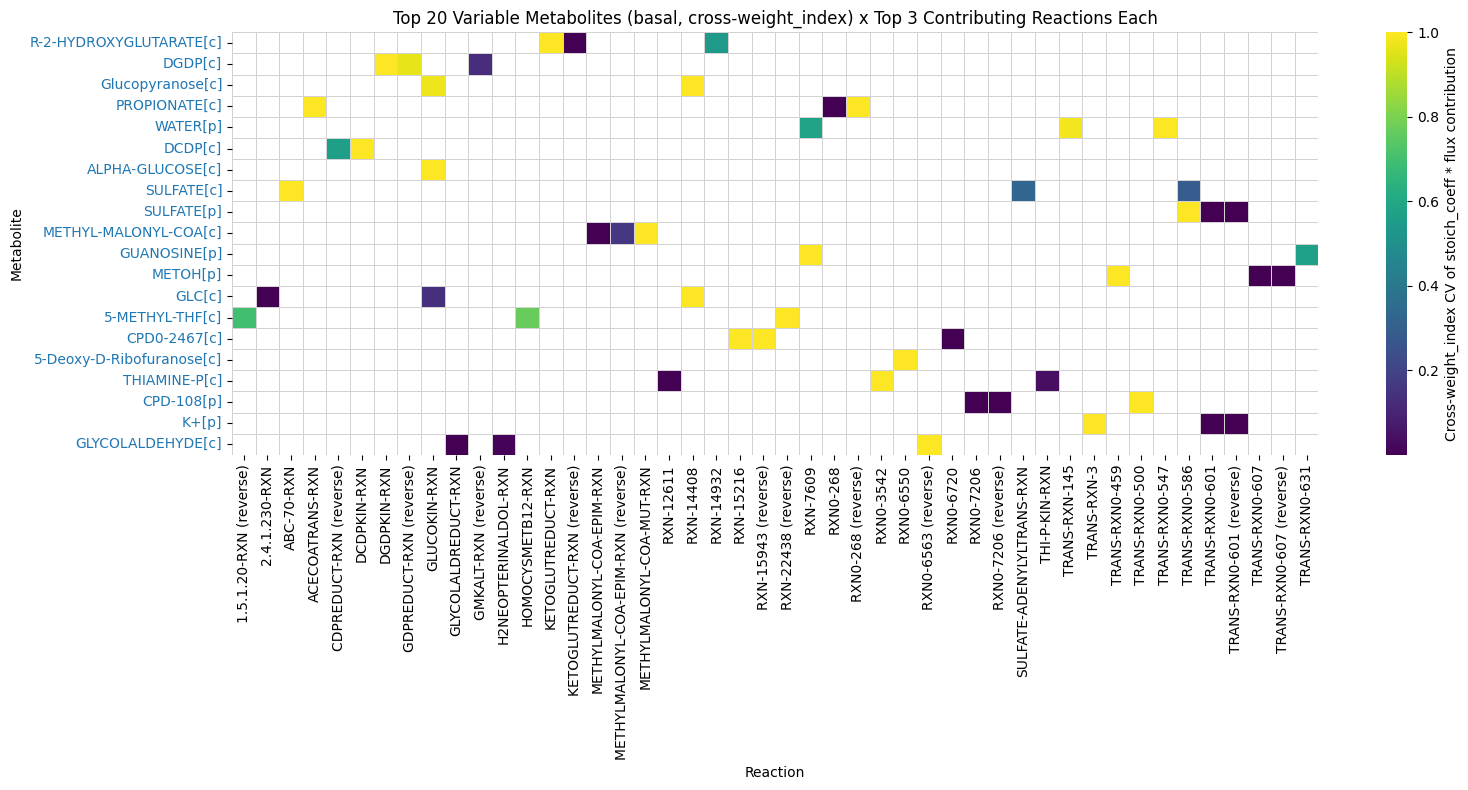

In [54]:
import seaborn as sns

TOP_N_REACTIONS_PER_MET = 3


def solution_flux_avg_across_seeds(sims, condition, weight_index):
    labels = [
        lbl for lbl, s in sims.items()
        if s["condition"] == condition and s["weight_index"] == weight_index
    ]
    dfs = [
        pd.DataFrame(
            sims[lbl]["fba"]["solution_fluxes"], columns=sims[lbl]["metabolism"].reaction_names
        ).loc[1:]
        for lbl in labels
    ]
    return sum(dfs) / len(dfs)


def top_reactions_cross_weight(
    mets, df_S, weight_indices, solution_flux_by_weight, eps=EPS, top_n=TOP_N_REACTIONS_PER_MET
):
    """For each metabolite, its top-`top_n` nonzero reactions by |mean
    stoich_coeff * flux| averaged across weight_index -- long-form
    (metabolite, reaction, cv_across_weight), where cv_across_weight is the
    CV (std/|mean|) of that reaction's per-weight_index time-CV, taken
    across weight_index."""
    rows = []
    n_dropped = 0
    for met in mets:
        nz = df_S.loc[met]
        nz = nz[nz != 0]
        contribs = []
        for rxn, coeff in nz.items():
            per_weight_mean, per_weight_cv = [], []
            for wi in weight_indices:
                contrib = solution_flux_by_weight[wi][rxn] * coeff
                m, s = contrib.mean(), contrib.std()
                per_weight_mean.append(m)
                per_weight_cv.append(s / (abs(m) + eps))
            grand_mean = np.mean(per_weight_mean)
            cv_across = np.std(per_weight_cv) / (abs(np.mean(per_weight_cv)) + eps)
            contribs.append((rxn, grand_mean, cv_across))
        contribs.sort(key=lambda c: abs(c[1]), reverse=True)
        n_dropped += max(0, len(contribs) - top_n)
        for rxn, mean, cv_across in contribs[:top_n]:
            rows.append({"metabolite": met, "reaction": rxn, "cv_across_weight": cv_across})
    print(
        f"kept top {top_n} reactions/metabolite by |mean contribution| "
        f"(averaged across {len(weight_indices)} weight_index groups); dropped "
        f"{n_dropped} lower-flux reactions for readability"
    )
    return pd.DataFrame(rows)


def fba_rxn_to_base_keep_direction(fba_rxn_ids, metabolism):
    fba_reaction_ids_to_base_reaction_ids = metabolism.parameters[
        "fba_reaction_ids_to_base_reaction_ids"
    ]
    for rxn in fba_rxn_ids:
        base_rxn = fba_reaction_ids_to_base_reaction_ids[rxn]
        if "(reverse)" in rxn:
            base_rxn = f"{base_rxn} (reverse)"
        yield base_rxn


solution_flux_by_weight = {
    wi: solution_flux_avg_across_seeds(sims, "basal", wi) for wi in WEIGHT_INDICES_BASAL
}

heat_df = top_reactions_cross_weight(
    top20["metabolite"], df_S_ref, WEIGHT_INDICES_BASAL, solution_flux_by_weight
)

# Different FBA-specific reaction IDs (e.g. distinct IDs for the same base
# reaction acting on different substrate variants) can map to the same base
# reaction name -- collapse to that base name *before* pivoting, so a
# reaction shared by several metabolites gets ONE heatmap column (showing
# how many metabolites route through it) instead of one identically-labeled
# column per metabolite. aggfunc="mean" handles the rare case where a single
# metabolite's own top-3 list has two variant IDs that map to the same base.
heat_df["reaction"] = list(
    fba_rxn_to_base_keep_direction(
        heat_df["reaction"], sims["basal_4654_seed1"]["metabolism"]
    )
)

heat_pivot = heat_df.pivot_table(
    index="metabolite", columns="reaction", values="cv_across_weight", aggfunc="mean"
)
heat_pivot = heat_pivot.loc[top20["metabolite"]]  # keep CV-ranked row order
heat_pivot = heat_pivot.div(heat_pivot.max(axis=1), axis=0)  # normalize cv by row

fig, ax = plt.subplots(figsize=(max(10, 0.35 * heat_pivot.shape[1]), 8))
sns.heatmap(
    heat_pivot,
    cmap="viridis",
    linewidths=0.5,
    linecolor="lightgray",
    cbar_kws={"label": "Cross-weight_index CV of stoich_coeff * flux contribution"},
    ax=ax,
)
ax.set_xlabel("Reaction")
ax.set_ylabel("Metabolite")
ax.set_title(
    f"Top {len(top20)} Variable Metabolites (basal, cross-weight_index) x "
    f"Top {TOP_N_REACTIONS_PER_MET} Contributing Reactions Each"
)

# color the homeostatic metabolites
map_color = {"intermediate": "tab:blue", "homeostatic": "tab:orange"}
map_home = top20.set_index("metabolite")["kind"].map(map_color)
for label in ax.get_yticklabels():
    label.set_color(map_home[label.get_text()])

plt.tight_layout()
plt.savefig(f'notebooks/Heena notebooks/JGI/figures/top20_variable_metabolites_x_top{TOP_N_REACTIONS_PER_MET}_reactions.svg', dpi=300)
plt.show()

In [59]:
top20

weight_index,metabolite,kind,3472,3540,4654,mean_cv,cv_across_weight
0,R-2-HYDROXYGLUTARATE[c],intermediate,0.024144,0.024158,4.315703,1.454668,1.703294
1,DGDP[c],intermediate,0.860385,0.733054,0.036590,0.543343,0.816160
2,Glucopyranose[c],intermediate,0.125426,0.821639,0.365270,0.437445,0.808498
3,PROPIONATE[c],intermediate,1.814648,1.809478,0.125329,1.249818,0.779185
4,WATER[p],intermediate,0.427183,0.151660,0.868713,0.482519,0.749640
5,DCDP[c],intermediate,1.145466,1.065031,0.125426,0.778641,0.728357
6,ALPHA-GLUCOSE[c],intermediate,0.125426,0.855093,0.532656,0.504392,0.724939
7,SULFATE[c],intermediate,2.432431,0.693411,1.487664,1.537835,0.566117
8,SULFATE[p],intermediate,2.432431,0.693411,1.487664,1.537835,0.566117
9,METHYL-MALONYL-COA[c],intermediate,0.204896,0.194138,0.125426,0.174820,0.246615


In [61]:
metabolism.homeostatic_metabolites

array(['2-3-DIHYDROXYBENZOATE[c]', '2-KETOGLUTARATE[c]', '2-PG[c]',
       '2K-4CH3-PENTANOATE[c]', '4-AMINO-BUTYRATE[c]',
       '4-hydroxybenzoate[c]', 'ACETOACETYL-COA[c]', 'ACETYL-COA[c]',
       'ACETYL-P[c]', 'ADENINE[c]', 'ADENOSINE[c]', 'ADP-D-GLUCOSE[c]',
       'ADP[c]', 'AMP[c]', 'ANTHRANILATE[c]', 'APS[c]', 'ARG[c]',
       'ASN[c]', 'ATP[c]', 'BIOTIN[c]', 'C6[p]', 'CA+2[c]', 'CAMP[c]',
       'CARBAMYUL-L-ASPARTATE[c]', 'CARBON-DIOXIDE[c]', 'CDP[c]',
       'CHORISMATE[c]', 'CIS-ACONITATE[c]', 'CIT[c]', 'CL-[c]', 'CMP[c]',
       'CO+2[c]', 'CO-A[c]', 'CPD-12115[c]', 'CPD-12575[c]',
       'CPD-12819[c]', 'CPD-12824[c]', 'CPD-13469[c]', 'CPD-2961[c]',
       'CPD-8260[c]', 'CPD-9956[c]', 'CPD0-939[c]', 'CTP[c]', 'CYS[c]',
       'CYTIDINE[c]', 'CYTOSINE[c]', 'D-ALA-D-ALA[c]',
       'D-SEDOHEPTULOSE-7-P[c]', 'DAMP[c]', 'DATP[c]', 'DCTP[c]',
       'DEOXY-RIBOSE-5P[c]', 'DEOXYADENOSINE[c]', 'DEOXYGUANOSINE[c]',
       'DGMP[c]', 'DGTP[c]', 'DI-H-OROTATE[c]',
       'DIHYDRO

## Item 3: Variability Across Time

The CV above collapses the full 1500-step trajectory into one number per
metabolite per weight_index. To see how a metabolite's raw trajectory shape
actually differs across objective-weight choices (rather than just its
summary CV), overlay each weight_index's seed-averaged per-timestep `dm/dt`
proxy for the top metabolites from Item 4.

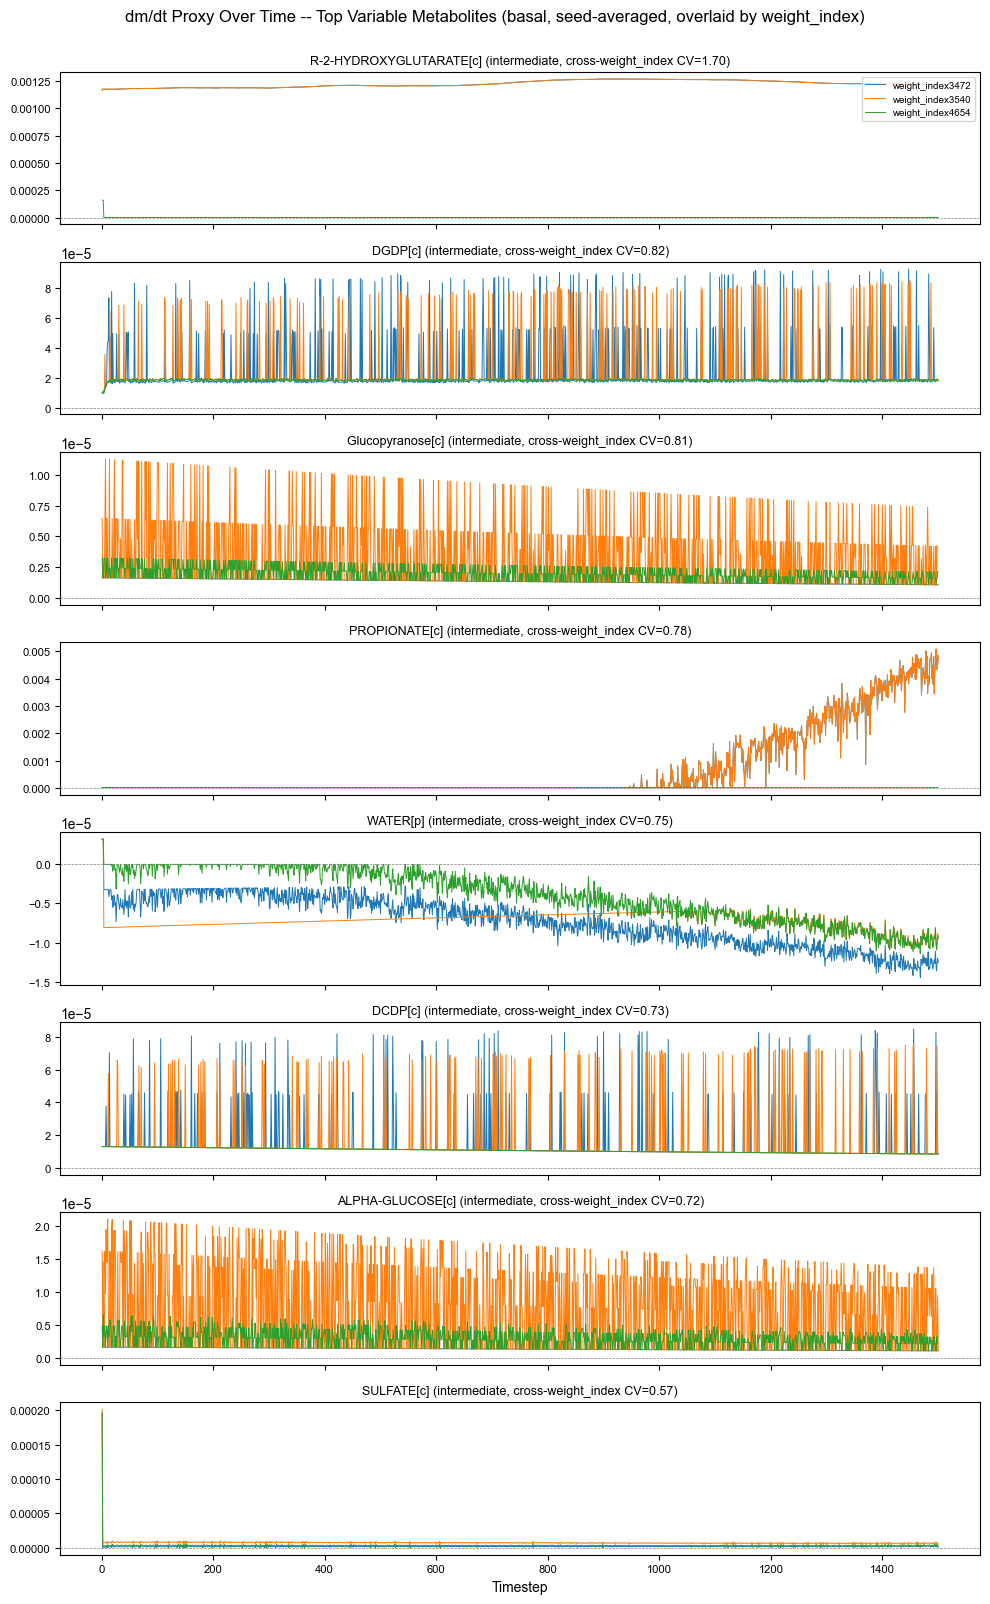

In [13]:
def series_avg_across_seeds(sims, condition, weight_index, field):
    labels = [
        lbl for lbl, s in sims.items()
        if s["condition"] == condition and s["weight_index"] == weight_index
    ]
    dfs = [sims[lbl][field] for lbl in labels]
    return sum(dfs) / len(dfs)


prod_dmdt_by_weight = {
    wi: series_avg_across_seeds(sims, "basal", wi, "prod_dmdt") for wi in WEIGHT_INDICES_BASAL
}
est_home_by_weight = {
    wi: series_avg_across_seeds(sims, "basal", wi, "est_home") for wi in WEIGHT_INDICES_BASAL
}

N_TIME_METS = 8
time_mets = top20.head(N_TIME_METS)

fig, axes = plt.subplots(
    len(time_mets), 1, figsize=(10, 2.0 * len(time_mets)), sharex=True
)
for ax, (_, row) in zip(axes, time_mets.iterrows()):
    met, kind = row["metabolite"], row["kind"]
    for wi in WEIGHT_INDICES_BASAL:
        series = (
            prod_dmdt_by_weight[wi][met]
            if kind == "intermediate"
            else est_home_by_weight[wi][met]
        )
        ax.plot(series.index, series.values, linewidth=0.7, label=f"weight_index{wi}")
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.set_title(
        f"{met} ({kind}, cross-weight_index CV={row['cv_across_weight']:.2f})", fontsize=9
    )
    ax.tick_params(labelsize=8)
axes[0].legend(fontsize=7, loc="upper right")
axes[-1].set_xlabel("Timestep")
fig.suptitle(
    "dm/dt Proxy Over Time -- Top Variable Metabolites "
    "(basal, seed-averaged, overlaid by weight_index)",
    y=1.0,
)
plt.tight_layout()
plt.show()

## Item 2: Variability Across Conditions -- Basal vs With-AA

Repeats Item 4's cross-weight_index CV computation for the `with_aa`
condition and compares against basal. Both use all weight_index groups
available in that condition, seed-averaged first -- this is a qualitative
comparison to see which metabolites are consistently variable across
conditions, not a statistical one. The statistical version is further down.

In [14]:
cv_summary_withaa, WEIGHT_INDICES_WITHAA = cross_weight_cv_summary(cv_long, "with_aa")
print(f"weight_index groups used for with_aa: {WEIGHT_INDICES_WITHAA}")

cv_summary_withaa.to_csv(
    "notebooks/Heena notebooks/JGI/data/with_aa_metabolite_cv.csv", index=False
)

comparison_conditions = cv_summary_basal[["metabolite", "kind", "cv_across_weight"]].merge(
    cv_summary_withaa[["metabolite", "kind", "cv_across_weight"]],
    on=["metabolite", "kind"],
    suffixes=("_basal", "_with_aa"),
)
print(
    f"{len(comparison_conditions)} metabolites have cross-weight_index CV "
    "computable in both conditions -- qualitative comparison only"
)
comparison_conditions.sort_values("cv_across_weight_basal", ascending=False).head(20)

with_aa: 347 metabolites present in all 3 weight_index groups (37 dropped for incomplete replication)
weight_index groups used for with_aa: ['3472', '3540', '4654']
340 metabolites have cross-weight_index CV computable in both conditions -- qualitative comparison only


weight_index,metabolite,kind,cv_across_weight_basal,cv_across_weight_with_aa
288,R-2-HYDROXYGLUTARATE[c],intermediate,1.703294,1.331290
130,DGDP[c],intermediate,0.816160,0.049672
184,Glucopyranose[c],intermediate,0.808498,0.753382
269,PROPIONATE[c],intermediate,0.779185,0.036512
333,WATER[p],intermediate,0.749640,0.006457
121,DCDP[c],intermediate,0.728357,0.099796
30,ALPHA-GLUCOSE[c],intermediate,0.724939,0.973819
308,SULFATE[p],intermediate,0.566117,0.232530
307,SULFATE[c],intermediate,0.566117,0.232530
225,METHYL-MALONYL-COA[c],intermediate,0.246615,0.006017


### With-AA Diversified Candidate Shortlist

Same Item 4b pipeline (candidate pool by `cv_across_weight`, currency
exclusion, reaction-sharing dedup) applied to the `with_aa` condition,
reusing the `CURRENCY`, `MAX_RXN_SIZE`, `rxn_sizes`, and `POOL_SIZE`
already defined above.

In [15]:
candidate_pool_withaa = (
    cv_summary_withaa.sort_values("cv_across_weight", ascending=False)
    .head(POOL_SIZE)
    .reset_index(drop=True)
)
candidate_pool_withaa[["metabolite", "kind", "cv_across_weight"]].head(10)

weight_index,metabolite,kind,cv_across_weight
0,L-ASPARTATE[p],intermediate,1.727910
1,L-DELTA1-PYRROLINE_5-CARBOXYLATE[c],intermediate,1.684390
2,GLT[p],intermediate,1.626146
3,R-2-HYDROXYGLUTARATE[c],intermediate,1.331290
4,L-ASPARTATE-SEMIALDEHYDE[c],intermediate,1.292684
5,VAL[p],intermediate,1.044964
6,ALPHA-GLUCOSE[c],intermediate,0.973819
7,P-HYDROXY-PHENYLPYRUVATE[c],intermediate,0.944245
8,2-KETO-3-METHYL-VALERATE[c],intermediate,0.938039
9,GLC[c],intermediate,0.878746


In [16]:
pool_withaa = candidate_pool_withaa[~candidate_pool_withaa["metabolite"].isin(CURRENCY)].reset_index(drop=True)
n_currency_dropped_withaa = len(candidate_pool_withaa) - len(pool_withaa)

rxn_sets_withaa = {}
for met in pool_withaa["metabolite"]:
    nz = df_S_ref.loc[met]
    rxn_sets_withaa[met] = {r for r in nz[nz != 0].index if rxn_sizes[r] <= MAX_RXN_SIZE}

mets_withaa = pool_withaa["metabolite"].tolist()
adj_withaa = {m: set() for m in mets_withaa}
for i, m1 in enumerate(mets_withaa):
    for m2 in mets_withaa[i + 1 :]:
        if rxn_sets_withaa[m1] & rxn_sets_withaa[m2]:
            adj_withaa[m1].add(m2)
            adj_withaa[m2].add(m1)

visited_withaa, clusters_withaa = set(), []
for m in mets_withaa:
    if m in visited_withaa:
        continue
    stack, comp = [m], []
    while stack:
        cur = stack.pop()
        if cur in visited_withaa:
            continue
        visited_withaa.add(cur)
        comp.append(cur)
        stack.extend(adj_withaa[cur] - visited_withaa)
    clusters_withaa.append(comp)

score_map_withaa = dict(zip(pool_withaa["metabolite"], pool_withaa["cv_across_weight"]))
reps_withaa = [max(c, key=lambda m: score_map_withaa[m]) for c in clusters_withaa]
diversified_shortlist_withaa = (
    pool_withaa[pool_withaa["metabolite"].isin(reps_withaa)]
    .sort_values("cv_across_weight", ascending=False)
    .reset_index(drop=True)
)

print(
    f"candidate pool: {len(candidate_pool_withaa)} ({n_currency_dropped_withaa} currency "
    f"metabolites excluded) -> {len(clusters_withaa)} reaction-sharing clusters "
    f"-> {len(diversified_shortlist_withaa)}-metabolite diversified shortlist"
)
for c in clusters_withaa:
    if len(c) > 1:
        dropped = [m for m in c if m not in reps_withaa]
        kept = [m for m in c if m in reps_withaa][0]
        print(f"  kept {kept!r}, dropped (same reaction-neighborhood): {dropped}")

diversified_shortlist_withaa[["metabolite", "kind"] + WEIGHT_INDICES_WITHAA + ["mean_cv", "cv_across_weight"]]

candidate pool: 40 (0 currency metabolites excluded) -> 25 reaction-sharing clusters -> 25-metabolite diversified shortlist
  kept 'L-DELTA1-PYRROLINE_5-CARBOXYLATE[c]', dropped (same reaction-neighborhood): ['L-GLUTAMATE_GAMMA-SEMIALDEHYDE[c]']
  kept 'GLT[p]', dropped (same reaction-neighborhood): ['4-AMINO-BUTYRATE[p]', 'NA+[c]', 'VAL[p]', 'ACET[c]', 'ACETALD[c]', 'GAP[c]', 'INDOLE[c]']
  kept 'ALPHA-GLUCOSE[c]', dropped (same reaction-neighborhood): ['ALPHA-GLC-6-P[c]', 'Glucopyranose[c]', 'GLC[c]']
  kept 'P-HYDROXY-PHENYLPYRUVATE[c]', dropped (same reaction-neighborhood): ['CPD-479[c]', '2-KETO-3-METHYL-VALERATE[c]']
  kept 'OH-PYR[c]', dropped (same reaction-neighborhood): ['CPD-26279[c]']
  kept 'SULFATE[c]', dropped (same reaction-neighborhood): ['SULFATE[p]']


weight_index,metabolite,kind,3472,3540,4654,mean_cv,cv_across_weight
0,L-ASPARTATE[p],intermediate,0.006913,25.622879,0.033995,8.554596,1.727910
1,L-DELTA1-PYRROLINE_5-CARBOXYLATE[c],intermediate,28.799317,0.206543,0.331788,9.779216,1.684390
2,GLT[p],intermediate,0.016535,1.188051,0.034020,0.412869,1.626146
3,R-2-HYDROXYGLUTARATE[c],intermediate,0.019037,0.018473,0.205660,0.081057,1.331290
4,L-ASPARTATE-SEMIALDEHYDE[c],intermediate,0.055157,0.054658,0.539544,0.216453,1.292684
5,ALPHA-GLUCOSE[c],intermediate,6.235744,0.581927,2.166857,2.994843,0.973819
6,P-HYDROXY-PHENYLPYRUVATE[c],intermediate,13.172181,6.107003,0.657069,6.645418,0.944245
7,OH-PYR[c],intermediate,0.719944,0.045715,0.766330,0.510663,0.789804
8,CARBON-DIOXIDE[p],intermediate,0.015388,0.014050,0.034606,0.021348,0.538745
9,OXALO-SUCCINATE[c],intermediate,0.061807,0.133137,0.055740,0.083561,0.515080


In [17]:
diversified_shortlist_withaa.to_csv(
    "notebooks/Heena notebooks/JGI/data/with_aa_metabolite_cv_diversified.csv",
    index=False
)

## Statistical Analysis: Basal vs With-AA (Per Objective Weight)

Since `weight_index` isn't safe to pool with `seed` (see the analysis
above), this comparison runs once per `weight_index`, pairing `basal`
against `with_aa` by matching `seed` (n=2 pairs each).

**Caveat**: a paired t-test with n=2 (1 degree of freedom) is numerically
valid but statistically fragile -- it can produce a very small p-value from
just two points if they happen to point the same direction, regardless of
whether that reflects a real, reproducible effect. Treat the p-values below
as a weak, reference-only signal, not a real significance claim.

The more trustworthy result is **direction consistency**: for each
metabolite, does the sign of the basal-vs-with_aa fold change agree between
the two independent `weight_index` groups? Agreement there means the effect
shows up under two genuinely different model configurations, which is much
stronger evidence than either group's own p-value.

In [18]:
comparison_condition_3472 = paired_test_across(
    cv_long[cv_long.weight_index == "3472"],
    "condition", "basal", "with_aa", ["seed"], min_pairs=2,
)
comparison_condition_4654 = paired_test_across(
    cv_long[cv_long.weight_index == "4654"],
    "condition", "basal", "with_aa", ["seed"], min_pairs=2,
)

for wi, comp in [("3472", comparison_condition_3472), ("4654", comparison_condition_4654)]:
    print(
        f"weight_index={wi}: {len(comp)} metabolites tested (n=2 pairs each); "
        f"{(comp['pval_adj'] < 0.05).sum()} 'significant' at FDR<0.05 -- "
        "treat with the n=2 caveat above"
    )

weight_index=3472: 342 metabolites tested (n=2 pairs each); 339 'significant' at FDR<0.05 -- treat with the n=2 caveat above
weight_index=4654: 354 metabolites tested (n=2 pairs each); 348 'significant' at FDR<0.05 -- treat with the n=2 caveat above


341 metabolites tested under both weight_index groups; 332 (97.4%) agree on direction


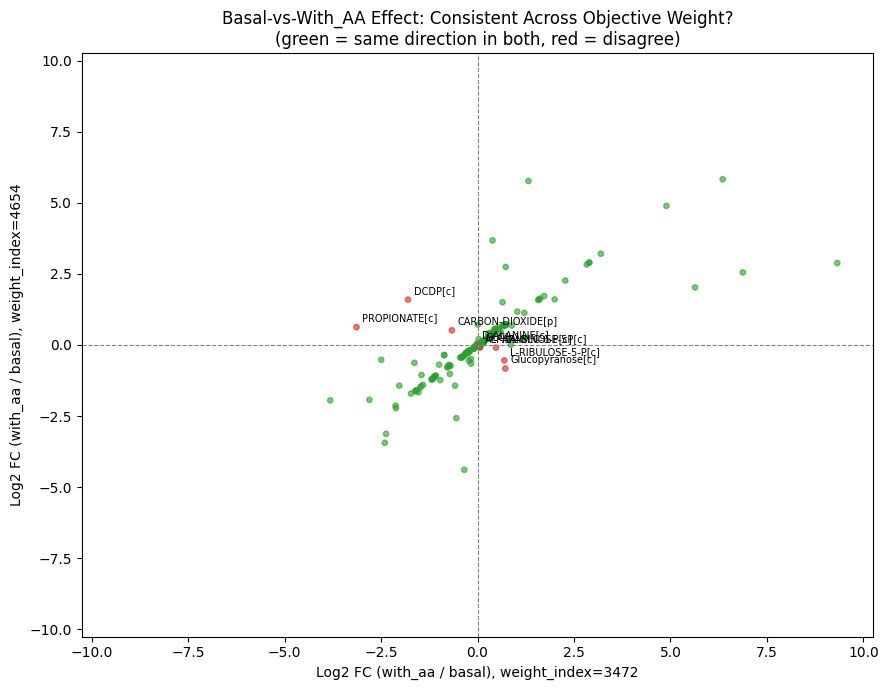

In [62]:
weight_consistency = comparison_condition_3472[["metabolite", "kind", "log2FC"]].merge(
    comparison_condition_4654[["metabolite", "kind", "log2FC"]],
    on=["metabolite", "kind"],
    suffixes=("_3472", "_4654"),
)
weight_consistency["consistent_direction"] = np.sign(
    weight_consistency["log2FC_3472"]
) == np.sign(weight_consistency["log2FC_4654"])

print(
    f"{len(weight_consistency)} metabolites tested under both weight_index groups; "
    f"{weight_consistency['consistent_direction'].sum()} "
    f"({weight_consistency['consistent_direction'].mean():.1%}) agree on direction"
)

fig, ax = plt.subplots(figsize=(9, 7))
colors = weight_consistency["consistent_direction"].map({True: "tab:green", False: "tab:red"})
ax.scatter(
    weight_consistency["log2FC_3472"], weight_consistency["log2FC_4654"],
    c=colors, alpha=0.6, s=15,
)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
lim = weight_consistency[["log2FC_3472", "log2FC_4654"]].abs().max().max() * 1.1
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel("Log2 FC (with_aa / basal), weight_index=3472")
ax.set_ylabel("Log2 FC (with_aa / basal), weight_index=4654")
ax.set_title(
    "Basal-vs-With_AA Effect: Consistent Across Objective Weight?\n"
    "(green = same direction in both, red = disagree)"
)

# label the disagreeing (red) metabolites -- these are the ones where the
# basal-vs-with_aa direction depends on which weight_index you happen to use
red_points = weight_consistency[~weight_consistency["consistent_direction"]]
for _, row in red_points.iterrows():
    ax.annotate(
        row["metabolite"],
        (row["log2FC_3472"], row["log2FC_4654"]),
        textcoords="offset points",
        xytext=(4, 4),
        fontsize=7,
    )
plt.tight_layout()
plt.savefig(f'notebooks/Heena notebooks/JGI/figures/basal_vs_with_aa_fc_consistency_across_weight_index.svg', dpi=300)
plt.show()